In [1]:
from obspy import read
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional
from scipy.signal import butter, filtfilt

path = "./DEC26DATA/CI_CPO/*.mseed"

def medFiler(h):
    for i in range(1,h.size-1):
        h[i] = (h[i-1]+h[i+1])/2
    
    return h

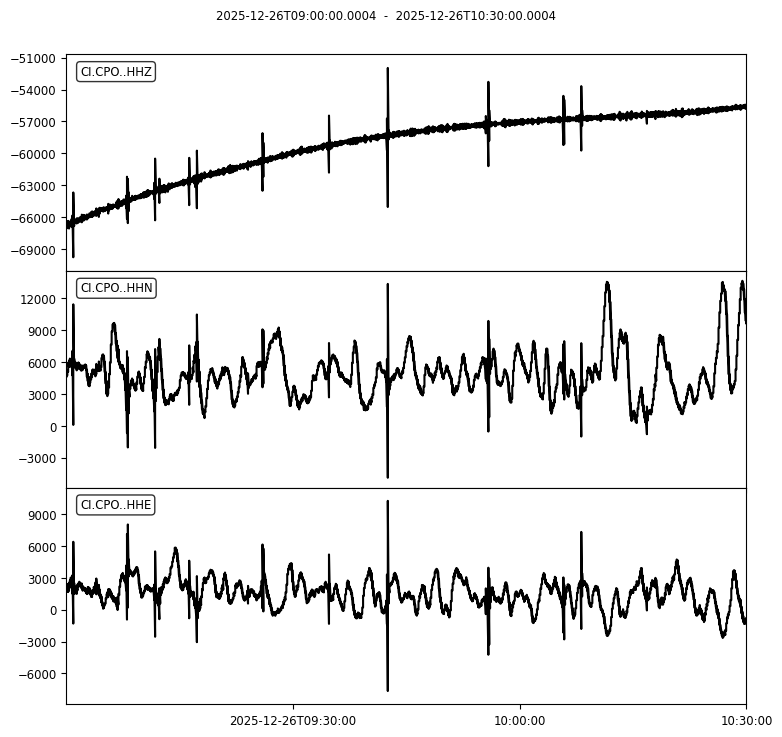

In [2]:
st = read(path)
#st.write("combined.mseed", format="MSEED")
st.plot();

In [ ]:
st[0].data = medFiler(st[0].data)
st[1].data = medFiler(st[1].data)
st[2].data = medFiler(st[2].data)
#3

In [4]:
def highpass_filter(data, cutoff=0.001, fs=0.01, order=5):
    """
    Apply a highpass Butterworth filter.
    
    Parameters:
        data   : your signal (numpy array)
        cutoff : cutoff frequency in Hz (default 0.001)
        fs     : sampling frequency of your signal in Hz (default 1.0)
        order  : filter order — higher = sharper cutoff (default 5)
    """
    
    nyq = fs / 2
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)


In [5]:
st[0].data = highpass_filter(st[0].data)
st[1].data = highpass_filter(st[1].data)
st[2].data = highpass_filter(st[2].data)


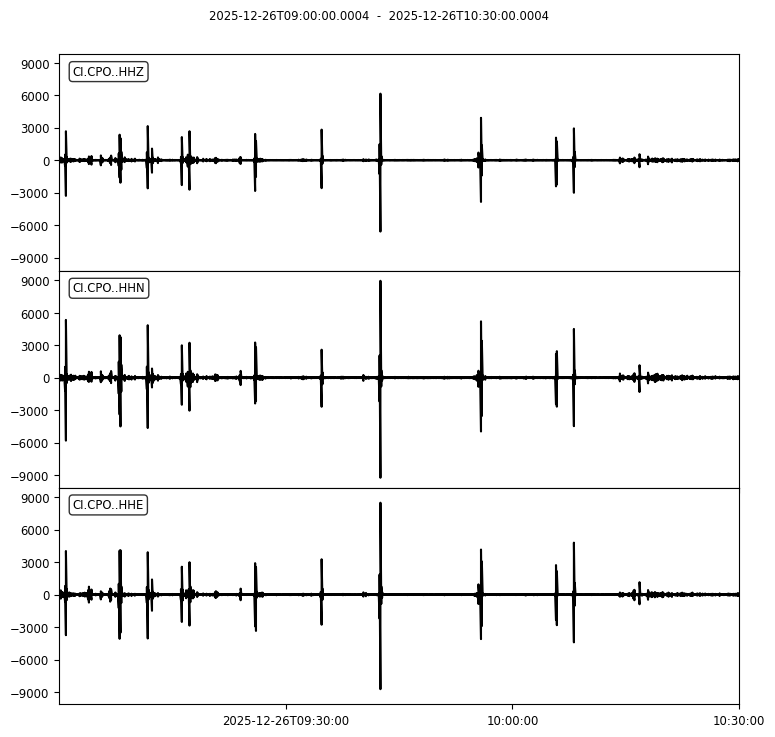

In [6]:
st.plot();